# 5. Нейросетевая аппроксимация

Сравниваем два способа по одним данным:
1. **Поправка к расчёту:** сеть учит $Y-Y_{\mathrm{model}}$, результат $Y_{\mathrm{model}}+\mathrm{NN}(x,y,t)$.
2. **Прямая аппроксимация:** сеть учит $Y$, результат $\mathrm{NN}(x,y,t)$.

$Y$ — показания 16 датчиков из The Well. Это внешний численный эталон; для эксперимента с реальными измерениями меняется источник $Y$. Модель —  отдельный расчёт акустики на грубой сетке. Одна сеть работает сразу для всех датчиков.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.ndimage import map_coordinates

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "waves/synthetic/well.py").exists())
sys.path.insert(0, str(ROOT / "waves/synthetic"))
import well

torch.set_num_threads(1)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

TASK, RUN = "discontinuous", 0
N_MODEL = 65
STEPS, LR = 8000, 1e-3
SEED = 0

discontinuous, расчёт 0: 16 датчиков, 102 отсчёта


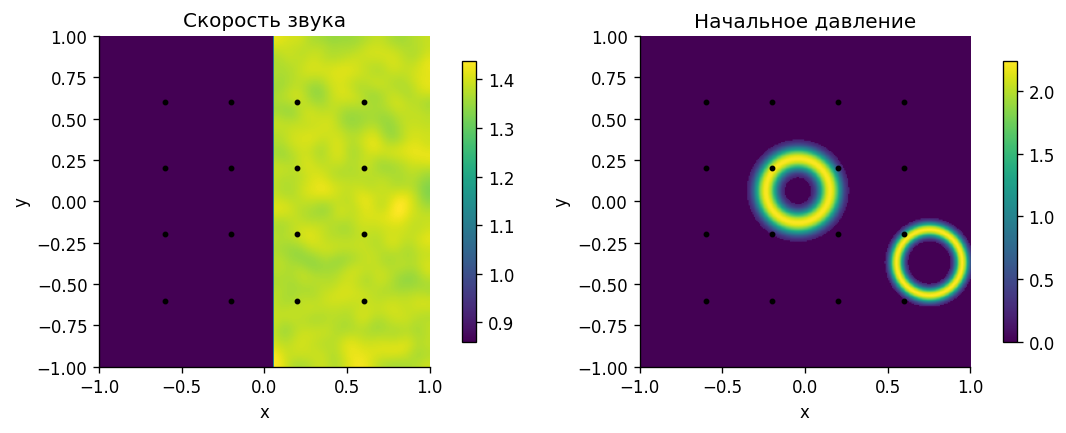

In [2]:
w = well.load(TASK)
t = w["time"].astype(float)
Y, points = well.records(w, RUN)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), layout="constrained")
for ax, field, title in zip(axes, [w["speed"][RUN], w["pressure"][RUN, 0]],
                           ["Скорость звука", "Начальное давление"]):
    im = ax.imshow(field.T, origin="lower", extent=(-1, 1, -1, 1))
    ax.plot(*points.T, "k.", ms=5)
    ax.set(title=title, xlabel="x", ylabel="y")
    fig.colorbar(im, ax=ax, shrink=0.85)
plt.show()
print(f"{TASK}, расчёт {RUN}: {Y.shape[0]} датчиков, {Y.shape[1]} отсчёта")

## Наш физический расчёт

Для постоянного модуля сжатия акустические уравнения дают
$$p_{tt}=\nabla\!\cdot(c^2\nabla p).$$
Начальное давление и скорость звука берём из эталона, начальная скорость частиц нулевая. Решаем на сетке $65\times65$: явная схема, гармоническое усреднение $c^2$ между узлами. По $x$ стенки отражают, по $y$ используем приближённое поглощающее условие $p_t\pm c p_y=0$. Показания модели интерполируем в точки датчиков.

Эталон получен другим решателем на сетке $256\times256$. Разность включает ошибки сетки и приближения границы. [Условия задачи The Well](https://polymathic-ai.org/the_well/datasets/acoustic_scattering_discontinuous/).

In [3]:
h = 2 / (N_MODEL - 1)
coords = np.meshgrid(*[np.linspace(0, w["speed"].shape[-1] - 1,
                                  N_MODEL)] * 2, indexing="ij")
p0 = map_coordinates(w["pressure"][RUN, 0], coords, order=1).astype(float)
c = map_coordinates(w["speed"][RUN], coords, order=1).astype(float)
c2 = c ** 2


def acceleration(p):
    """Дивергенция потока c² grad p с отражающими краями."""
    out = np.zeros_like(p)
    for axis in (0, 1):
        U, A = (np.moveaxis(v, axis, 0) for v in (p, c2))
        face = 2 * A[:-1] * A[1:] / (A[:-1] + A[1:])
        flux = face * np.diff(U, axis=0) / h
        q = np.zeros_like(U)
        q[:-1] += flux / h
        q[1:] -= flux / h
        q[[0, -1]] *= 2
        out += np.moveaxis(q, 0, axis)
    return out


substeps = int(np.ceil(np.diff(t).max() * c.max() * np.sqrt(2) / (0.45 * h)))
dt = (t[1] - t[0]) / substeps
p = p0.copy()
old = p + 0.5 * dt ** 2 * acceleration(p)
sensor_coords = (points.T + 1) / h
records = [map_coordinates(p, sensor_coords, order=1)]
for interval in np.diff(t):
    dt = interval / substeps
    for _ in range(substeps):
        new = 2 * p - old + dt ** 2 * acceleration(p)
        new[:, 0] = p[:, 0] + c[:, 0] * dt / h * (p[:, 1] - p[:, 0])
        new[:, -1] = p[:, -1] + c[:, -1] * dt / h * (p[:, -2] - p[:, -1])
        old, p = p, new
    records.append(map_coordinates(p, sensor_coords, order=1))
Y_model = np.array(records).T

## Обучение

Две одинаковые MLP: **3 → 64 → 64 → 1**, активация `tanh`. Вход — координаты датчика и время. Обучаем обычной MSE, Adam

20% моментов времени оставляем для проверки сразу у всех датчиков. Остальные моменты, включая начало и конец записи, используем для обучения. Проверяем **интерполяцию по времени** на тех же датчиках. Среднее и масштаб целевой величины считаем только по обучающим данным.

In [4]:
xy = np.repeat(points, len(t), axis=0)
time = np.tile(t, len(points))
X = torch.tensor(np.column_stack([xy, 2 * (time - t[0]) / (t[-1] - t[0]) - 1]),
                 dtype=torch.float32)
y, model = Y.ravel(), Y_model.ravel()

rng = np.random.default_rng(SEED)
test_times = np.sort(rng.choice(np.arange(1, len(t) - 1), len(t) // 5, replace=False))
test = np.tile(np.isin(np.arange(len(t)), test_times), len(points))
train = ~test
X_train = X[train]


def fit(target):
    """Обучение общей сети по значениям в датчиках."""
    torch.manual_seed(SEED)
    net = torch.nn.Sequential(torch.nn.Linear(3, 64), torch.nn.Tanh(),
                              torch.nn.Linear(64, 64), torch.nn.Tanh(),
                              torch.nn.Linear(64, 1))
    center, scale = target[train].mean(), target[train].std()
    scale = max(float(scale), 1e-12)
    target_train = torch.tensor((target[train] - center) / scale,
                                dtype=torch.float32)[:, None]
    opt = torch.optim.Adam(net.parameters(), lr=LR)
    losses = []
    for step in range(STEPS):
        opt.zero_grad()
        loss = ((net(X_train) - target_train) ** 2).mean()
        loss.backward()
        opt.step()
        if step % 100 == 0 or step == STEPS - 1:
            losses.append((step + 1, loss.item() * scale ** 2))
    with torch.no_grad():
        pred = net(X)[:, 0].numpy() * scale + center
    return pred.reshape(Y.shape), np.array(losses)


residual, loss_residual = fit(y - model)
Y_corrected = Y_model + residual
Y_direct, loss_direct = fit(y)

## Сравнение

Для обоих вариантов сравниваем **восстановленные показания** с одним эталоном:
$$\varepsilon=\frac{\|\widehat Y-Y\|}{\|Y\|}.$$
Нулевые показания дают ошибку 1. В обучении сеть поправки минимизирует ошибку разности; в таблице оценивается итог $Y_{\mathrm{model}}+\mathrm{NN}$.

Способ                 Обучение   Проверка
Наш расчёт                0.621      0.521
Расчёт + MLP              0.112      0.200
Прямая MLP                0.097      0.160


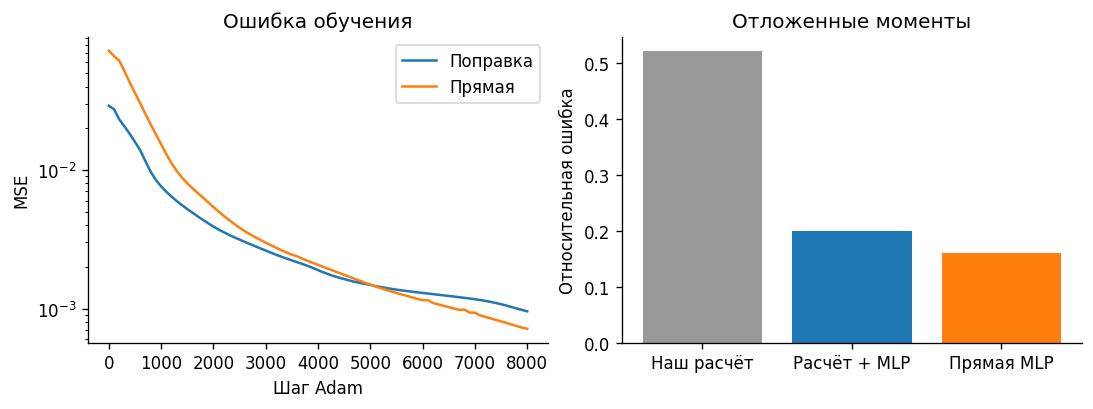

In [5]:
predictions = {"Наш расчёт": Y_model, "Расчёт + MLP": Y_corrected, "Прямая MLP": Y_direct}
errors = {}
print(f"{'Способ':20s} {'Обучение':>10s} {'Проверка':>10s}")
for name, pred in predictions.items():
    diff = (pred - Y).ravel()
    errors[name] = [np.linalg.norm(diff[mask]) / np.linalg.norm(y[mask])
                    for mask in (train, test)]
    print(f"{name:20s} {errors[name][0]:10.3f} {errors[name][1]:10.3f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.3), layout="constrained")
for name, history in [("Поправка", loss_residual), ("Прямая", loss_direct)]:
    axes[0].semilogy(history[:, 0], history[:, 1], label=name)
axes[0].set(xlabel="Шаг Adam", ylabel="MSE", title="Ошибка обучения")
axes[0].legend()
axes[1].bar(list(errors), [v[1] for v in errors.values()], color=["0.6", "C0", "C1"])
axes[1].set(ylabel="Относительная ошибка", title="Отложенные моменты")
plt.show()

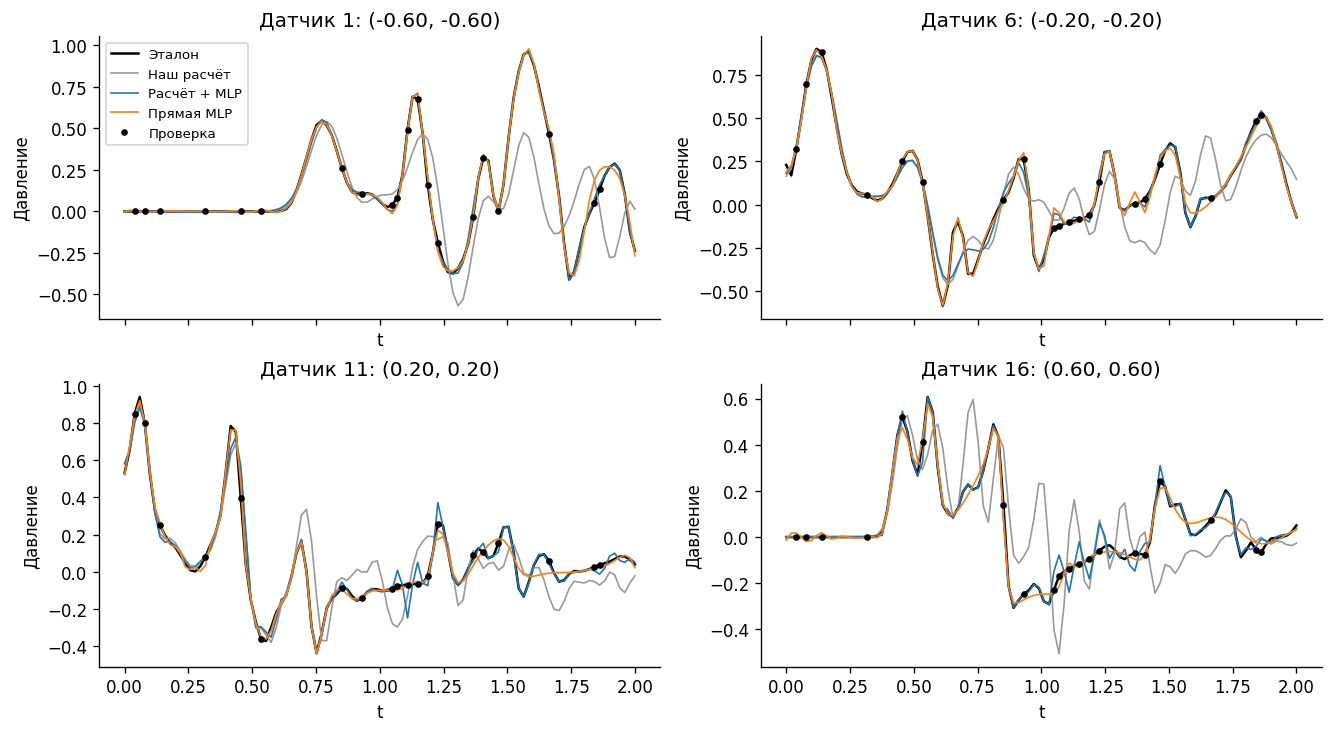

In [6]:
sensors = [0, 5, 10, 15]
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, layout="constrained")
for ax, i in zip(axes.flat, sensors):
    ax.plot(t, Y[i], "k", lw=1.5, label="Эталон")
    ax.plot(t, Y_model[i], color="0.6", lw=1, label="Наш расчёт")
    ax.plot(t, Y_corrected[i], color="C0", lw=1, label="Расчёт + MLP")
    ax.plot(t, Y_direct[i], color="C1", lw=1, label="Прямая MLP")
    ax.plot(t[test_times], Y[i, test_times], "ko", ms=3, label="Проверка")
    ax.set(title=f"Датчик {i + 1}: ({points[i, 0]:.2f}, {points[i, 1]:.2f})",
           xlabel="t", ylabel="Давление")
axes[0, 0].legend(fontsize=8)
plt.show()